# 05 - Topic Analysis

We build the speech topics two ways and compare them:

1. **Embedding-based** (BERTopic on the Jina vectors, `min_topic_size = 150`) - clusters by meaning.
2. **Text-based** (LDA on word counts) - clusters by word co-occurrence, no embeddings. LDA gets the *same number of topics* HDBSCAN found.

For the embedding side we keep two assignments: the raw one (BERTopic leaves the vague speeches as `-1`) and a reduced one where every leftover speech goes to its nearest topic. At the end we compare the two approaches and save everything.

In [1]:
!pip install bertopic nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.1 MB/s eta 0:00:00


In [2]:
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

## 1. Load the data

In [3]:
#embeddings
emb = pd.read_parquet("jina_v3_offtheshelf_full.parquet")
#speech texts
meta = pd.read_csv("speeches_main_2000_2021.csv", encoding="utf-8",
                   usecols=["id", "speechContent", "date"])
#merge
df = emb.merge(meta, on="id", how="left")
df = df[df["speechContent"].notna() & (df["speechContent"].str.strip() != "")].reset_index(drop=True)

docs = [unicodedata.normalize("NFC", t) for t in df["speechContent"].tolist()]
embeddings = np.array(df["embedding"].tolist(), dtype="float32")

print(f"{len(df):,} speeches")
print("umlaut check:", repr(docs[0][:100]))

105,020 speeches
umlaut check: 'Frau Präsidentin! Meine werten Kolleginnen und Kollegen! Liebe Kolleginnen und Kollegen von der Unio'


**105,020 speeches** loaded (text + embedding joined on the speech id). The umlaut check prints real ü / ä / ö, so the German text survived the import intact.

## Shared text settings (umlaut-safe)

In [4]:
def strip_accents(w):
    return unicodedata.normalize("NFKD", w).encode("ascii", "ignore").decode("ascii")

plenary = [
    "herr", "frau", "damen", "herren", "kollege", "kollegin", "kolleginnen",
    "kollegen", "präsident", "präsidentin", "dank", "danke", "vielen", "sehr",
    "geehrter", "geehrte", "liebe", "meine", "schon", "mehr", "gibt", "heute",
    "gesagt", "gesetzentwurf", "antrag", "deutschland", "bundesregierung",
    "können", "müssen", "worden", "ganz", "wäre", "gerne", "sagen", "geht", "immer",
]
filler = ["ja", "dafür", "natürlich", "tun", "gut", "wirklich", "wissen", "brauchen",
          "thema", "glaube", "wichtig", "deswegen", "punkt", "möchte", "bereits",
          "deshalb", "dabei", "sowie", "mal", "endlich", "eigentlich", "sage",
          "wer", "reden", "darüber", "nehmen", "hätte", "hätten", "sei", "herrn"]
base = set(stopwords.words("german")) | set(plenary) | set(filler)
german_stop = sorted(base | {strip_accents(w) for w in base})

german_token = r"(?u)\b[A-Za-zÄÖÜäöüß][A-Za-zÄÖÜäöüß-]+\b"

## 2. Embedding-based topics (BERTopic, min size 150).

In [5]:
vectorizer = CountVectorizer(stop_words=german_stop, strip_accents=None,
                             token_pattern=german_token, min_df=10, ngram_range=(1, 2))

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric="cosine", init="random", random_state=42)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    vectorizer_model=vectorizer,
    min_topic_size=150,
    calculate_probabilities=False,
    verbose=True,
)

topics_raw = topic_model.fit_transform(docs, embeddings=embeddings)[0]

2026-08-09 20:25:24,522 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-09 20:29:03,206 - BERTopic - Dimensionality - Completed ✓
2026-08-09 20:29:03,211 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-09 20:29:29,609 - BERTopic - Cluster - Completed ✓
2026-08-09 20:29:29,636 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-09 20:31:40,906 - BERTopic - Representation - Completed ✓


In [6]:
df["topic_emb_raw"] = topics_raw
topics_full = topic_model.reduce_outliers(docs, topics_raw, strategy="embeddings",
                                          embeddings=embeddings, threshold=0.0)
df["topic_emb_full"] = topics_full

n_topics = len([t for t in set(topics_raw) if t != -1])
print(f"{n_topics} embedding topics")
print(f"path A unassigned: {(df['topic_emb_raw']  == -1).mean():.0%}")
print(f"path B unassigned: {(df['topic_emb_full'] == -1).mean():.0%}")

113 embedding topics
path A unassigned: 34%
path B unassigned: 0%


BERTopic found **113 topics** from the embeddings. **Path A** leaves **34%** of speeches unassigned (`-1`) — the vague / mixed ones HDBSCAN won't force into a cluster. **Path B** reassigns those to their nearest topic, so every speech gets a label. At `min_topic_size=150` the topics stay balanced — no single dominating topic.

### Umlaut-correct topic labels

BERTopic's own labels strip the umlauts, so we build labels ourselves from a plain CountVectorizer (keeps umlauts) using an over-representation score.

In [7]:
label_vec = CountVectorizer(stop_words=german_stop, strip_accents=None,
                            token_pattern=german_token, min_df=20)
X_label = label_vec.fit_transform(docs)
vocab_label = np.array(label_vec.get_feature_names_out())
overall = np.asarray(X_label.sum(axis=0)).ravel() + 1

def label_topics(topic_col, n=3):
    labels, arr = {}, df[topic_col].to_numpy()
    for t in sorted(set(arr)):
        if t == -1:
            continue
        cnt = np.asarray(X_label[arr == t].sum(axis=0)).ravel()
        lift = (cnt / max(cnt.sum(), 1)) / (overall / overall.sum())
        lift[cnt < 20] = 0
        labels[t] = f"{t}: " + "/".join(vocab_label[lift.argsort()[::-1][:n]])
    return labels

emb_labels = label_topics("topic_emb_raw")

counts = df["topic_emb_raw"].value_counts()
overview = (pd.DataFrame([{"topic": t, "count": int(counts.get(t, 0)), "label": lab}
                          for t, lab in emb_labels.items()])
            .sort_values("count", ascending=False).reset_index(drop=True))
overview

,topic,count,label
0,0,4230,0: marktstabilitätsreserve/tehg/netznutzungsen...
1,1,3188,1: mehrstaatigkeit/lebensunterhaltssicherung/o...
2,2,2441,2: konventes/syriza/grexit
3,3,2341,3: passiv-aktiv-transfer/vermittlungshemmnisse...
4,4,2195,4: kitaqualität/partnerschaftsbonus/haushaltsf...
...,...,...,...
108,108,158,108: afrikapolitik/nepad/afrikaner
109,109,156,109: uribe/guerilla/colombia
110,110,156,110: winnenden/sportschützen/waffenbehörden
111,111,153,111: untersuchungsausschussgesetz/untersuchung...


The **113 topics, largest first**. The biggest is only ~4% of all speeches, so the distribution is balanced (no giant catch-all). Labels are each topic's most *over-represented* words, umlauts intact; the themes are specific and readable (energy, Greece/Grexit, migration, childcare, …).

## 3. Topics over time

Share of each year's speeches per topic. With this many topics one plot is unreadable, so we draw them in batches of ~10 (biggest topics first), once per path.

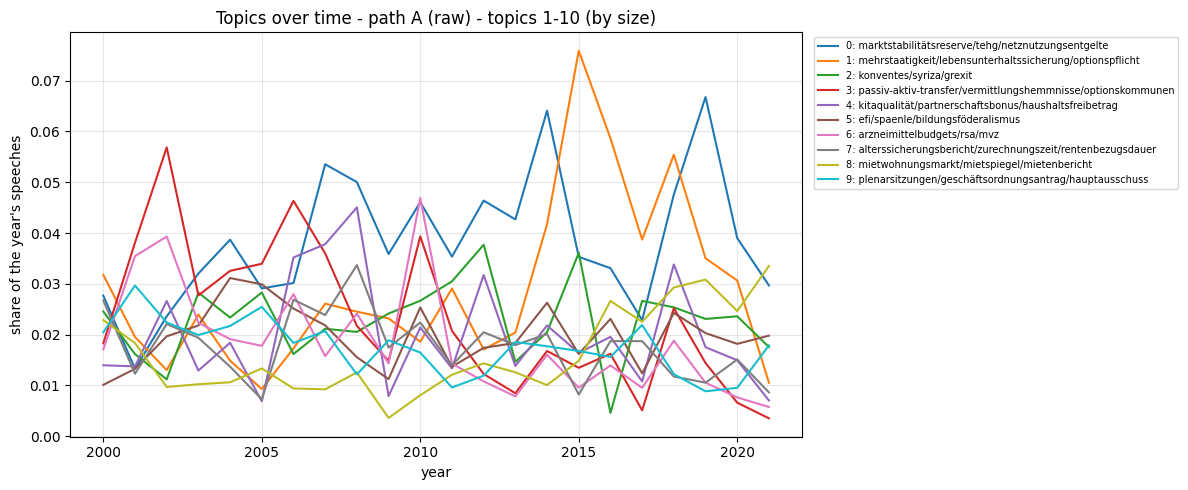

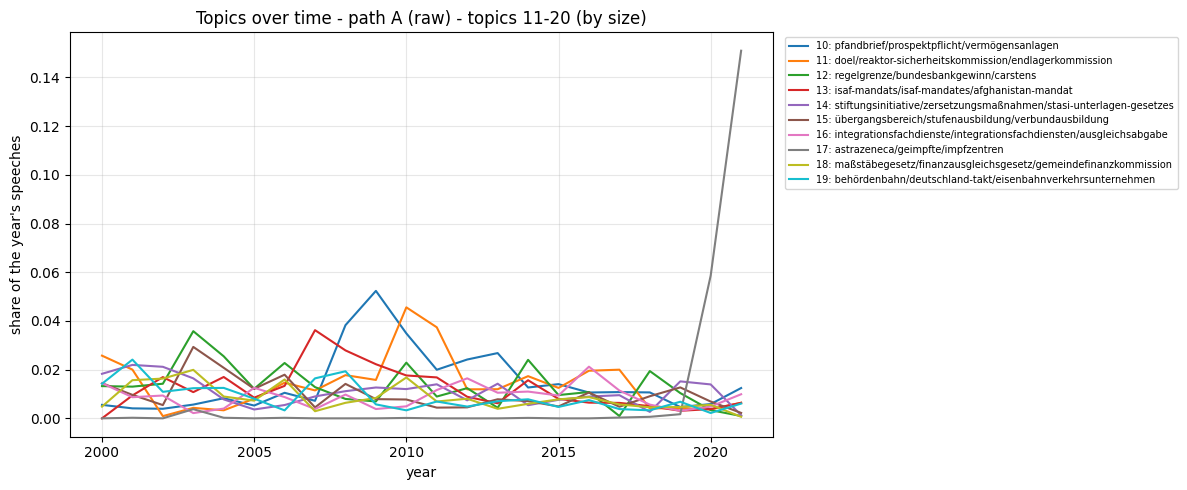

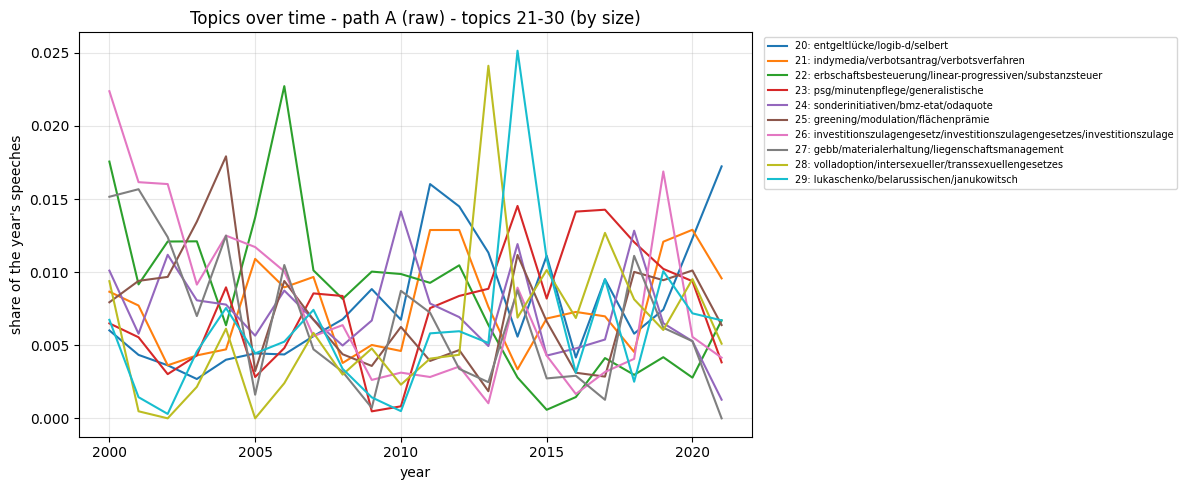

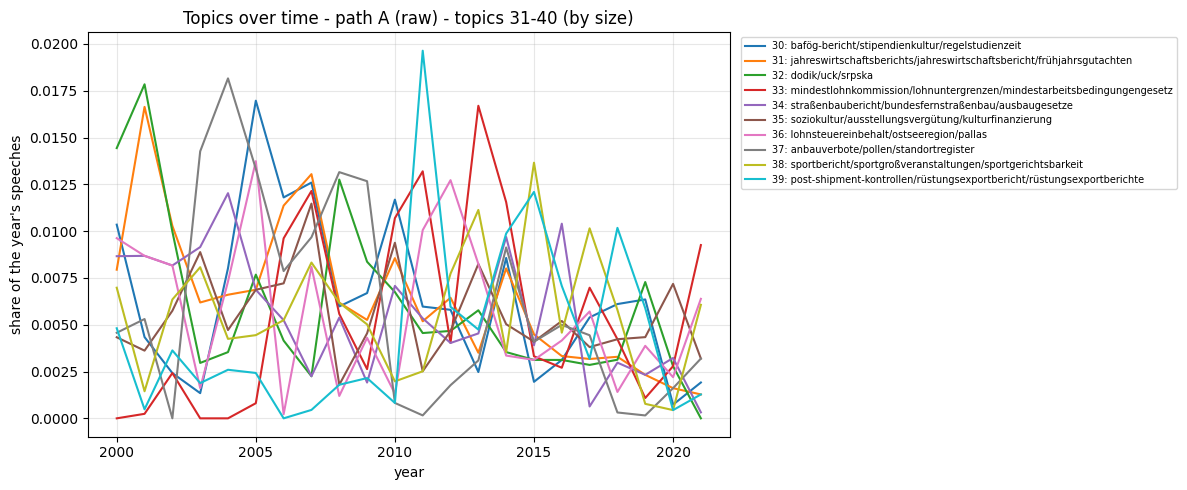

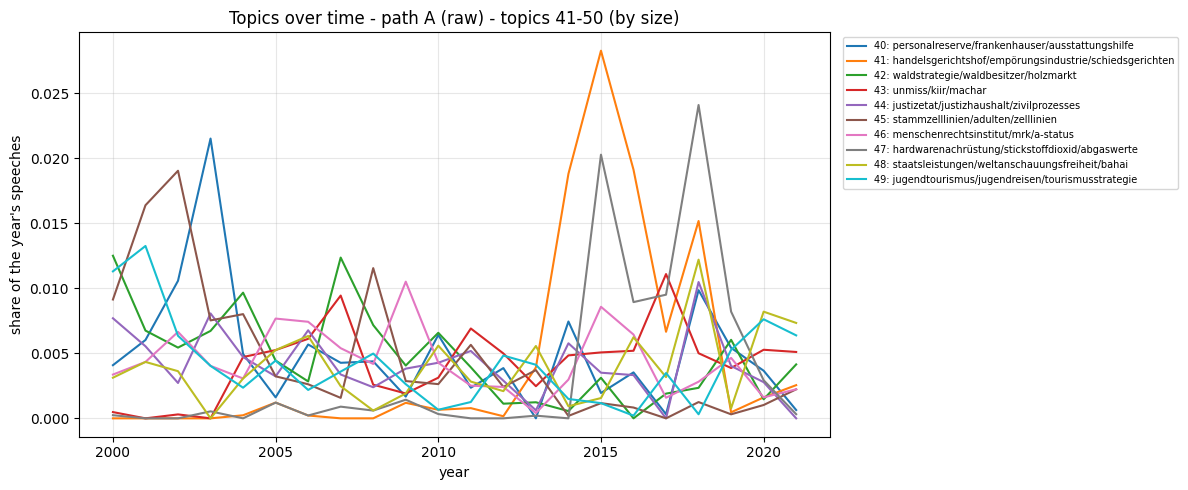

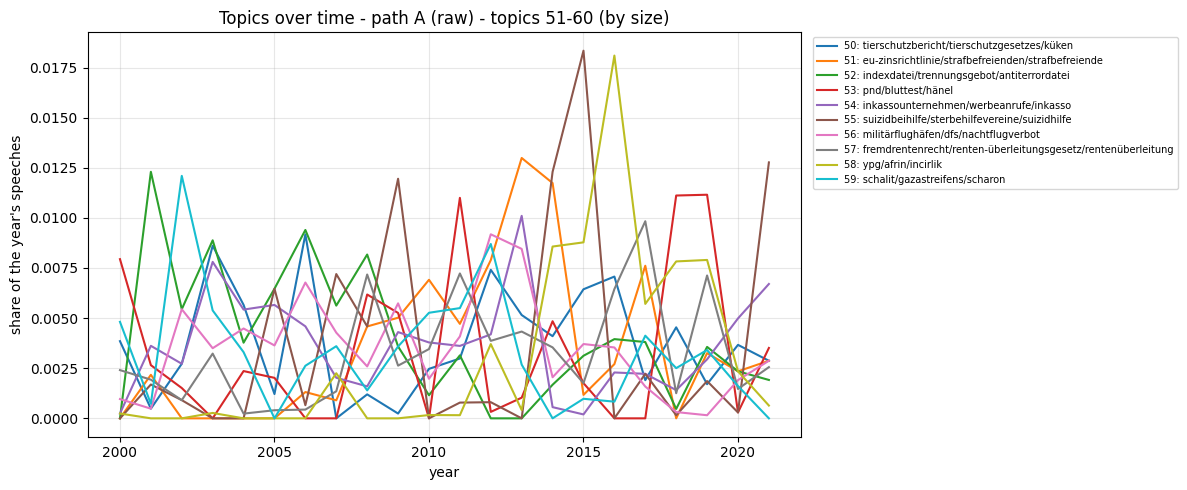

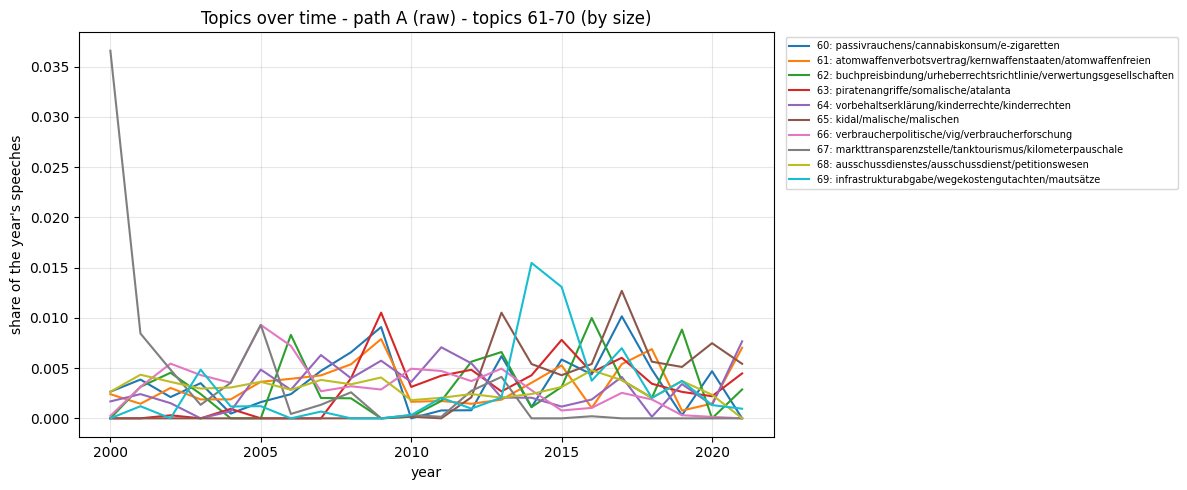

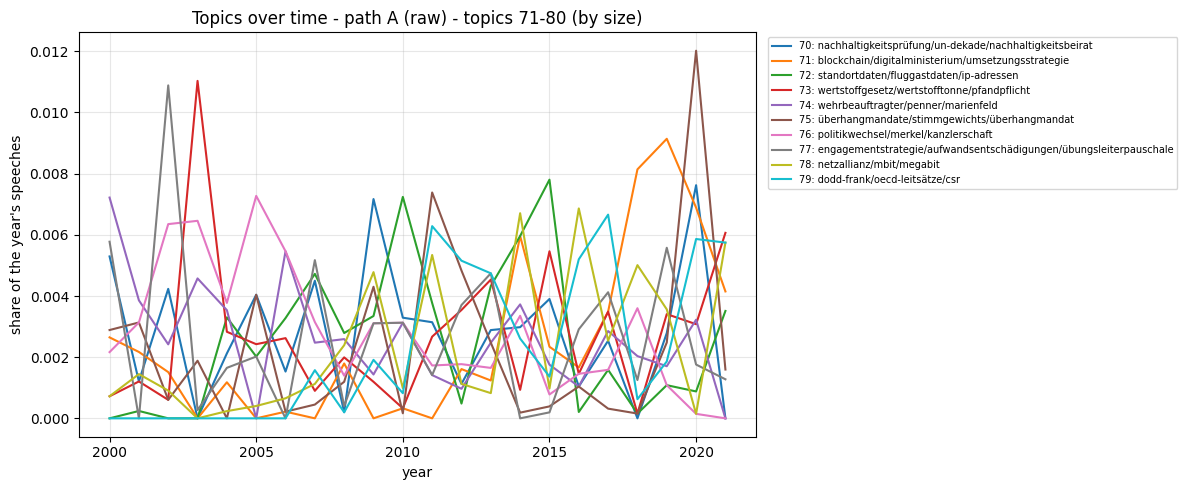

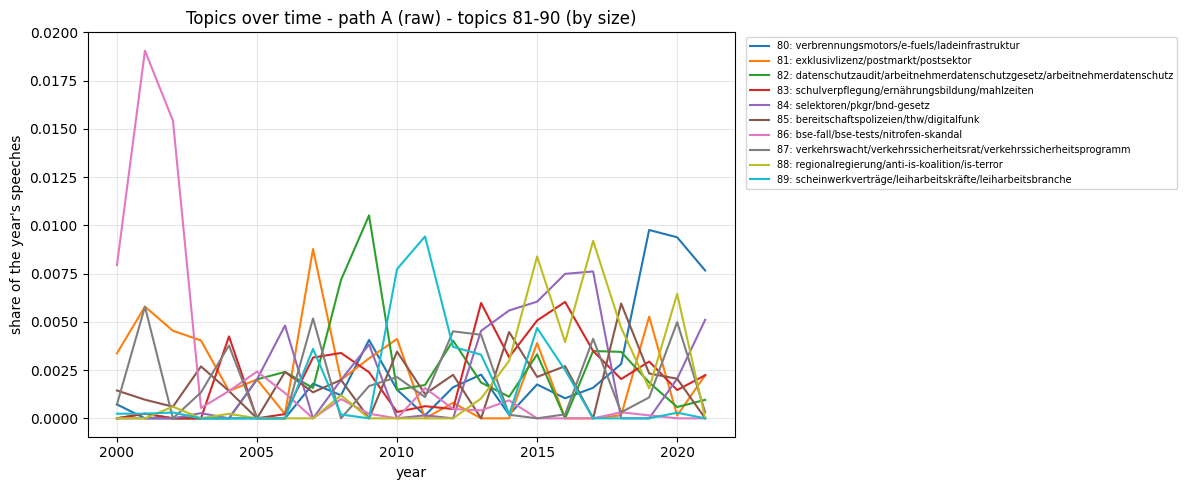

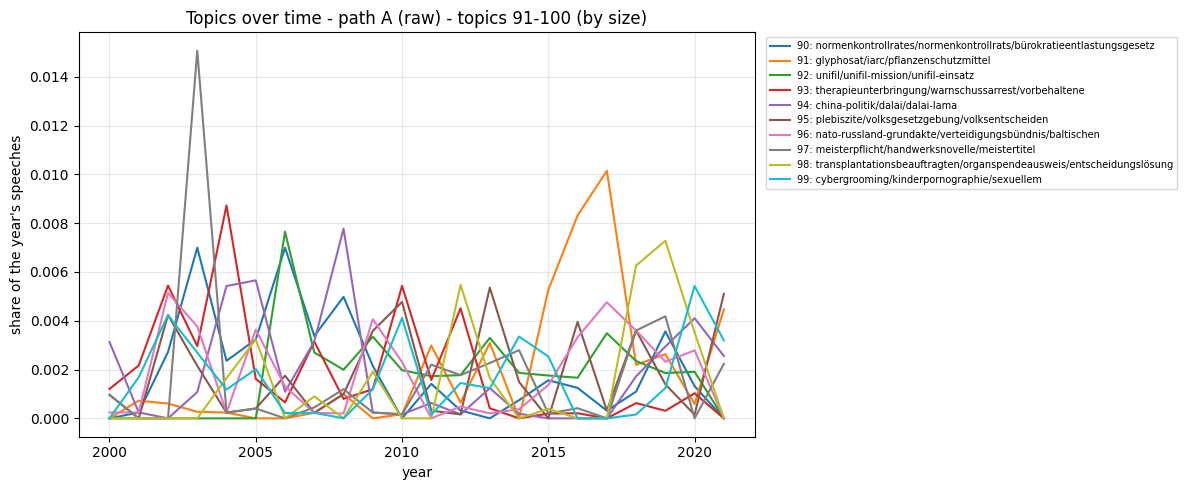

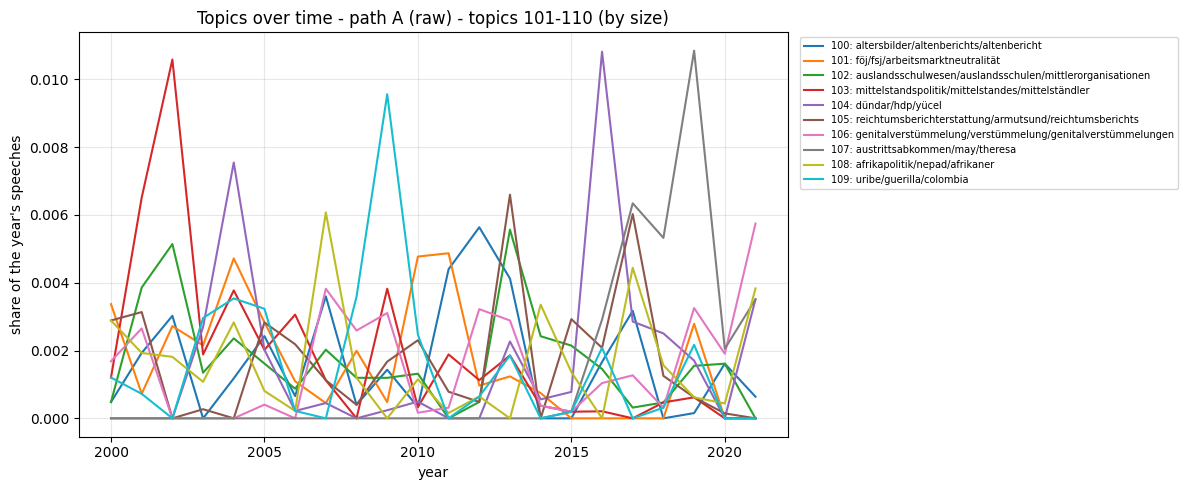

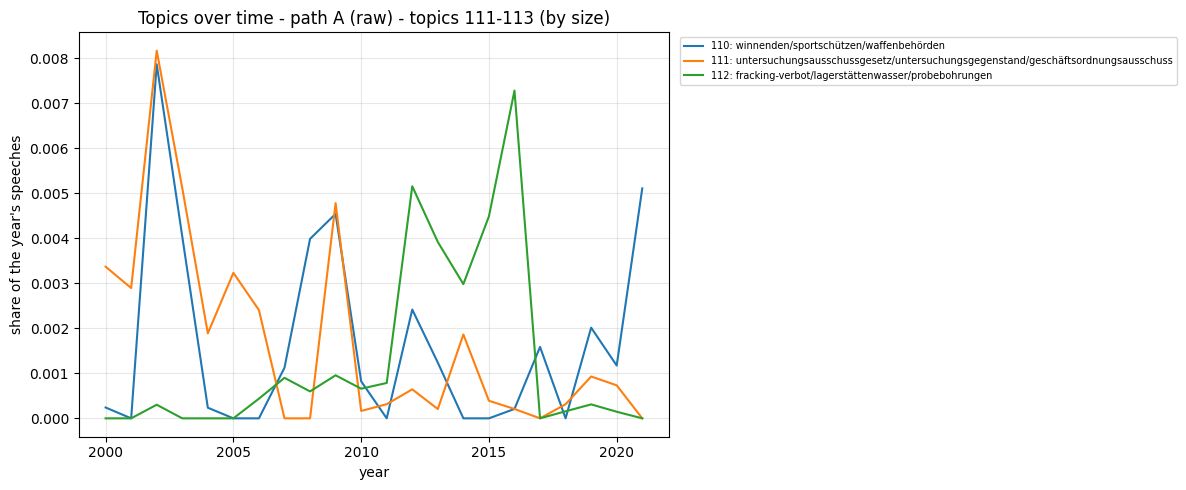

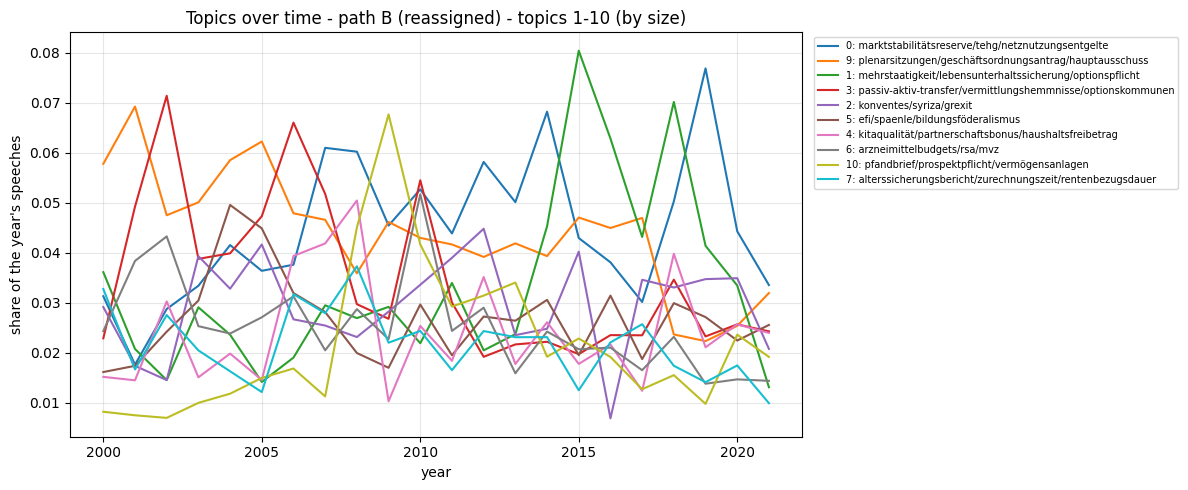

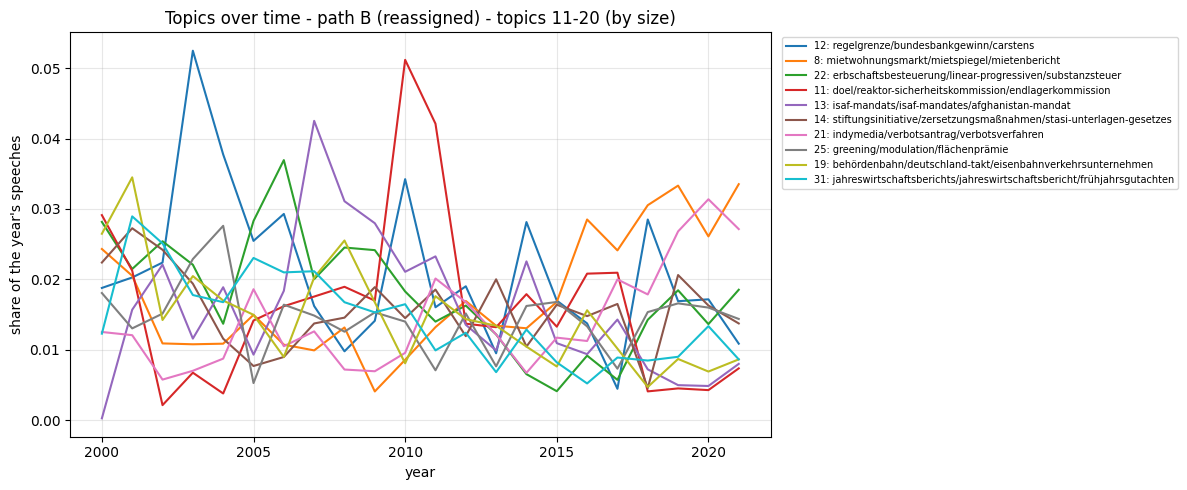

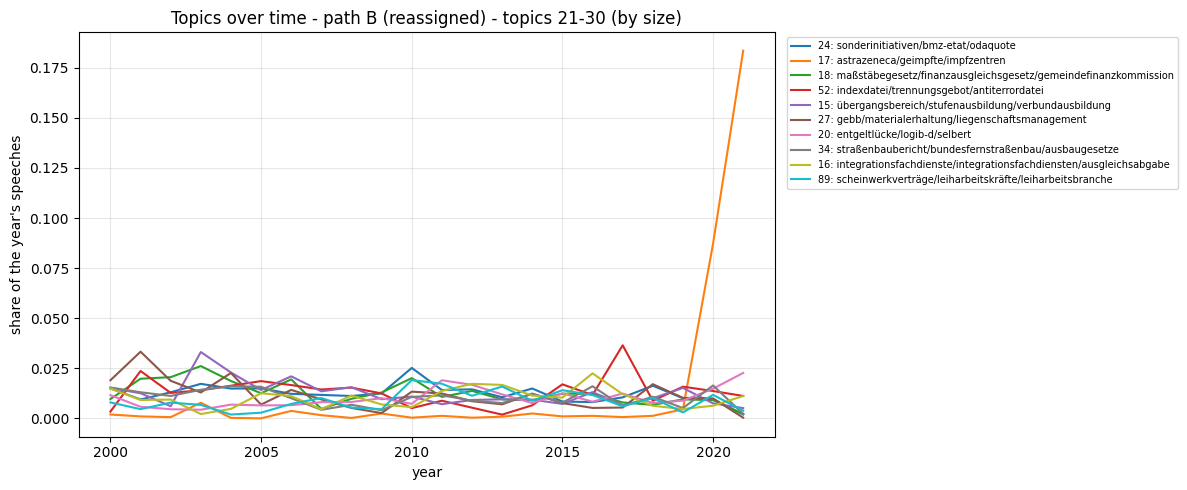

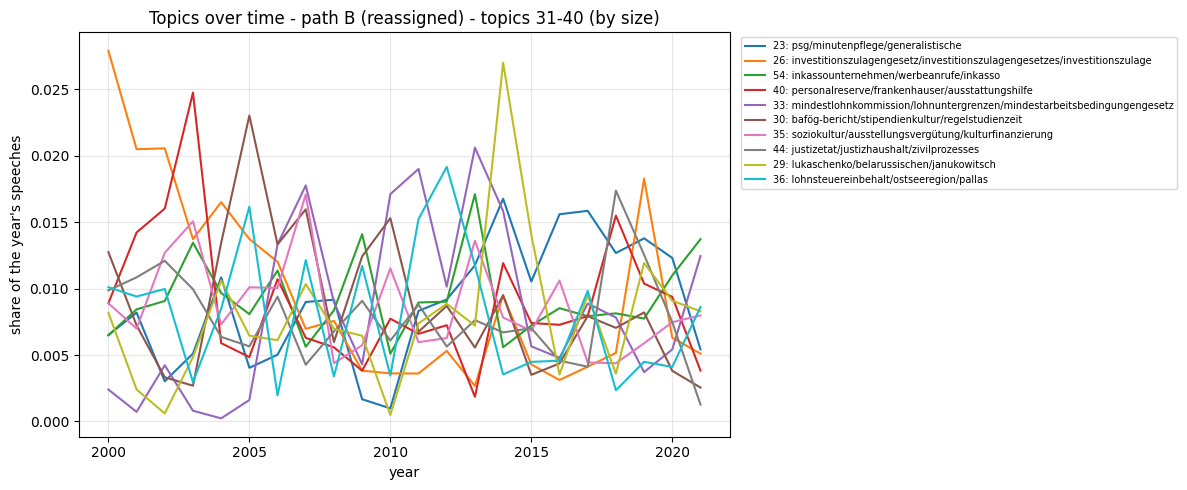

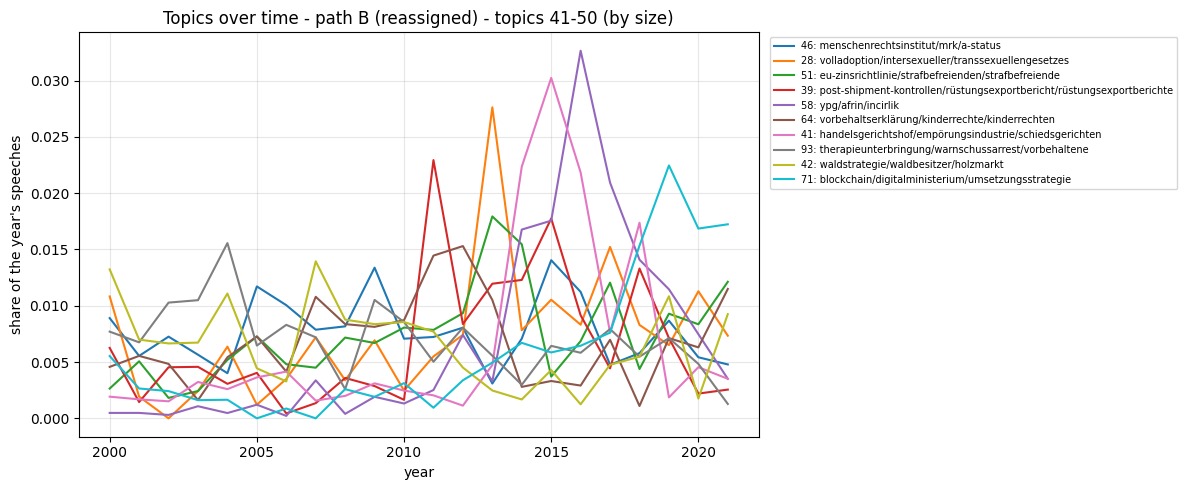

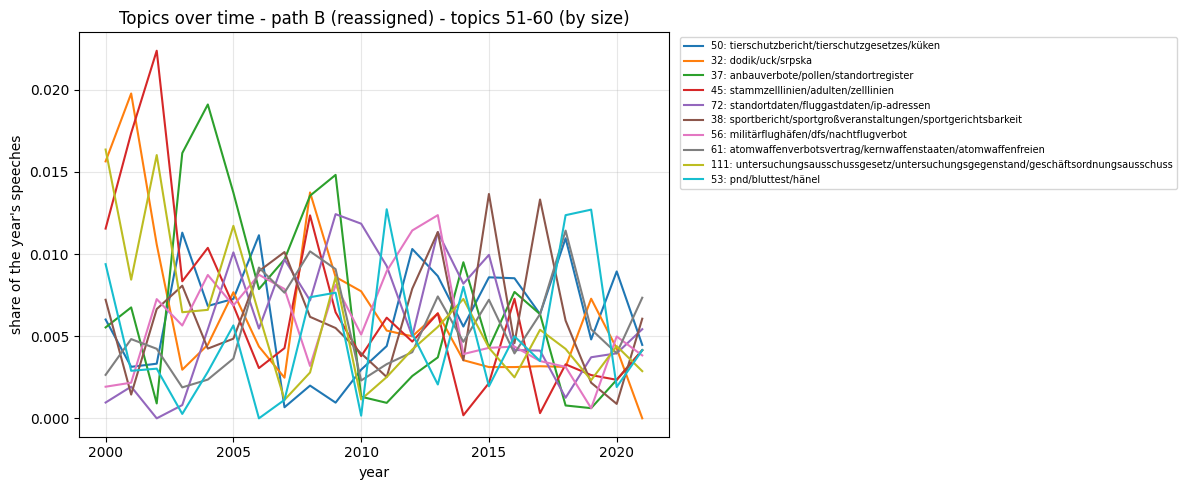

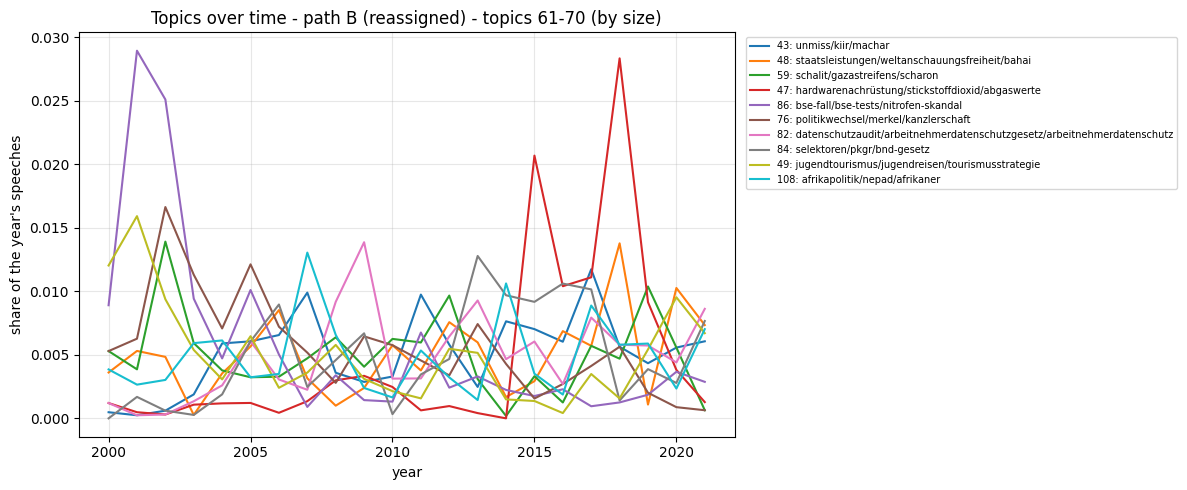

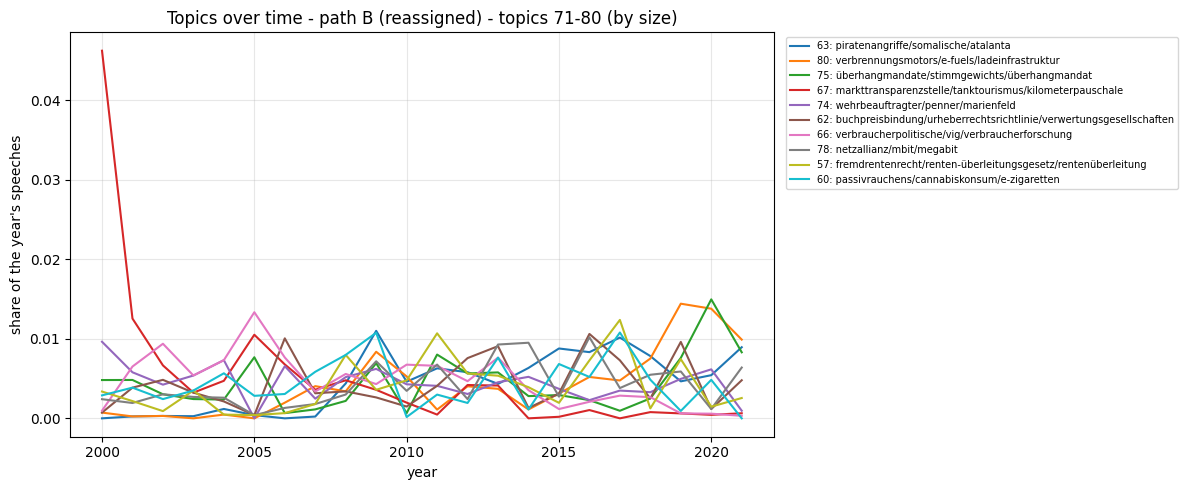

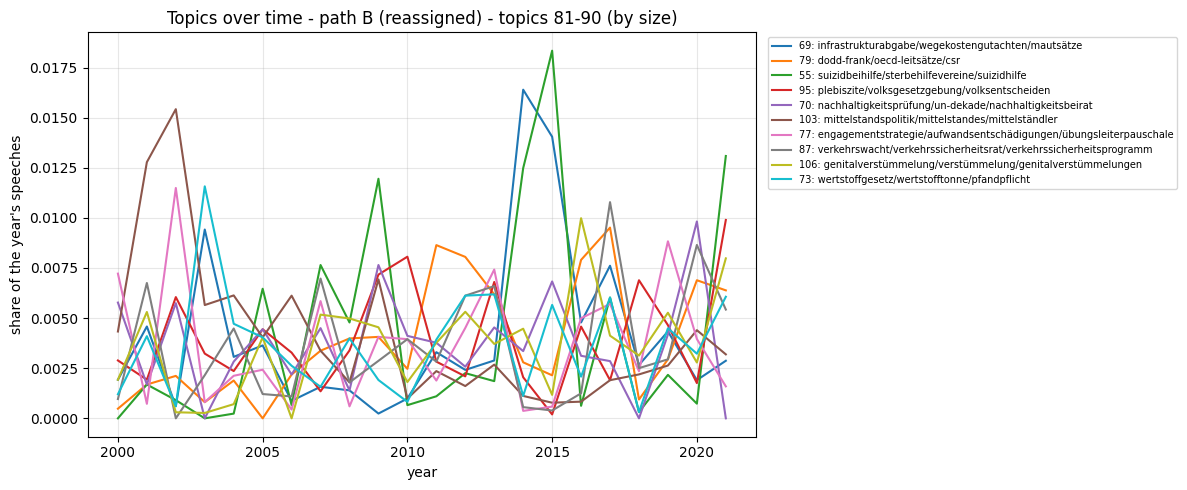

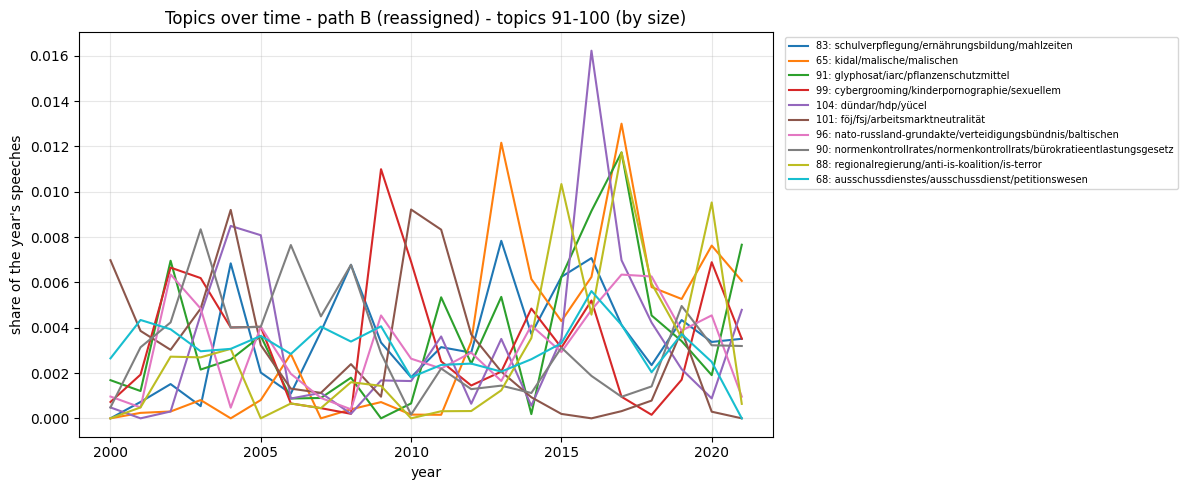

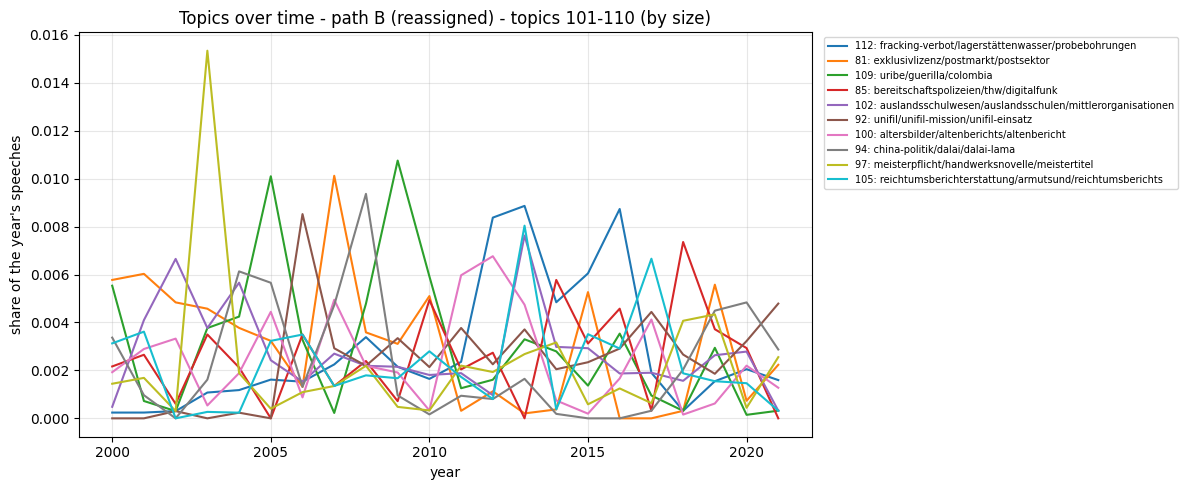

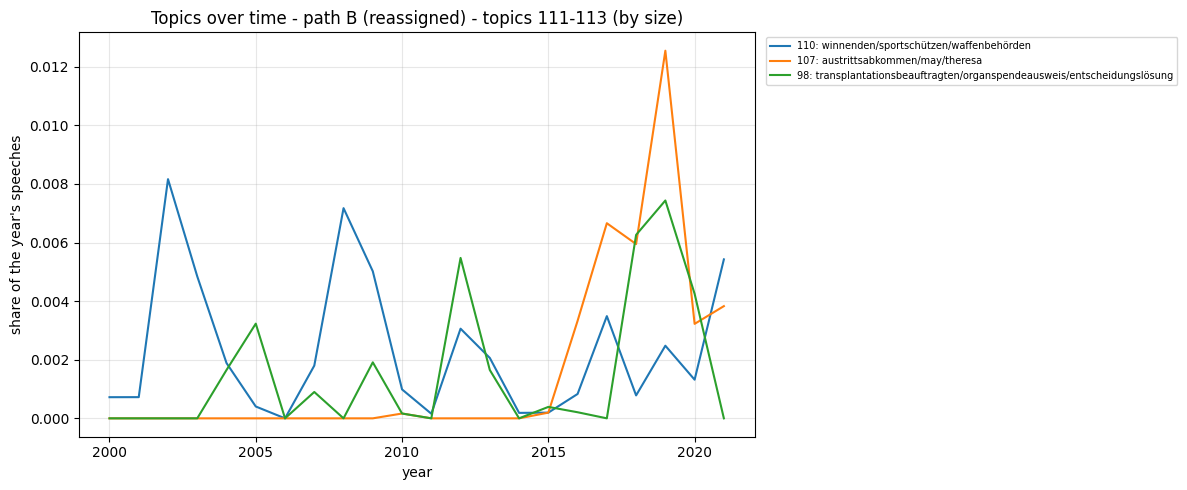

In [8]:
def topics_over_time(topic_col, title, per_plot=10):
    share = pd.crosstab(df["year"], df[topic_col], normalize="index")
    order = df.loc[df[topic_col] != -1, topic_col].value_counts().index.tolist()   # biggest first
    for i in range(0, len(order), per_plot):
        chunk = order[i:i + per_plot]
        ax = share[chunk].plot(figsize=(12, 5))
        ax.set_xlabel("year"); ax.set_ylabel("share of the year's speeches")
        ax.set_title(f"{title} - topics {i + 1}-{i + len(chunk)} (by size)")
        ax.legend([emb_labels[t] for t in chunk], bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=7)
        ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

topics_over_time("topic_emb_raw",  "Topics over time - path A (raw)")
topics_over_time("topic_emb_full", "Topics over time - path B (reassigned)")

Each line is a topic's **share of that year's speeches**. Event-driven topics rise and fall on cue (the pandemic topic from 2020, migration around 2015). Path A and Path B tell the same story; Path B's shares sit slightly higher because the reassigned 34% are spread back across the topics.

We could use this graphes also for event analysis.

## 4. Topic share per party

Share of each party's speeches per topic (row-normalised by party), all topics, once per path.

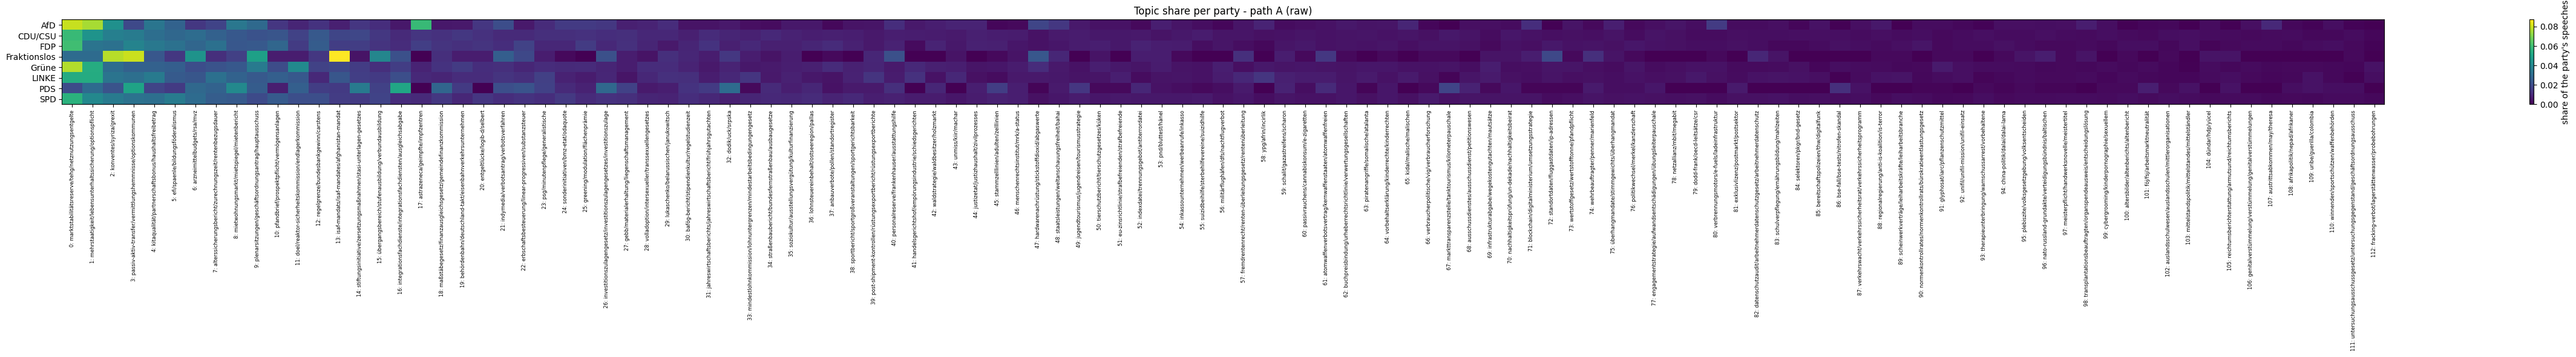

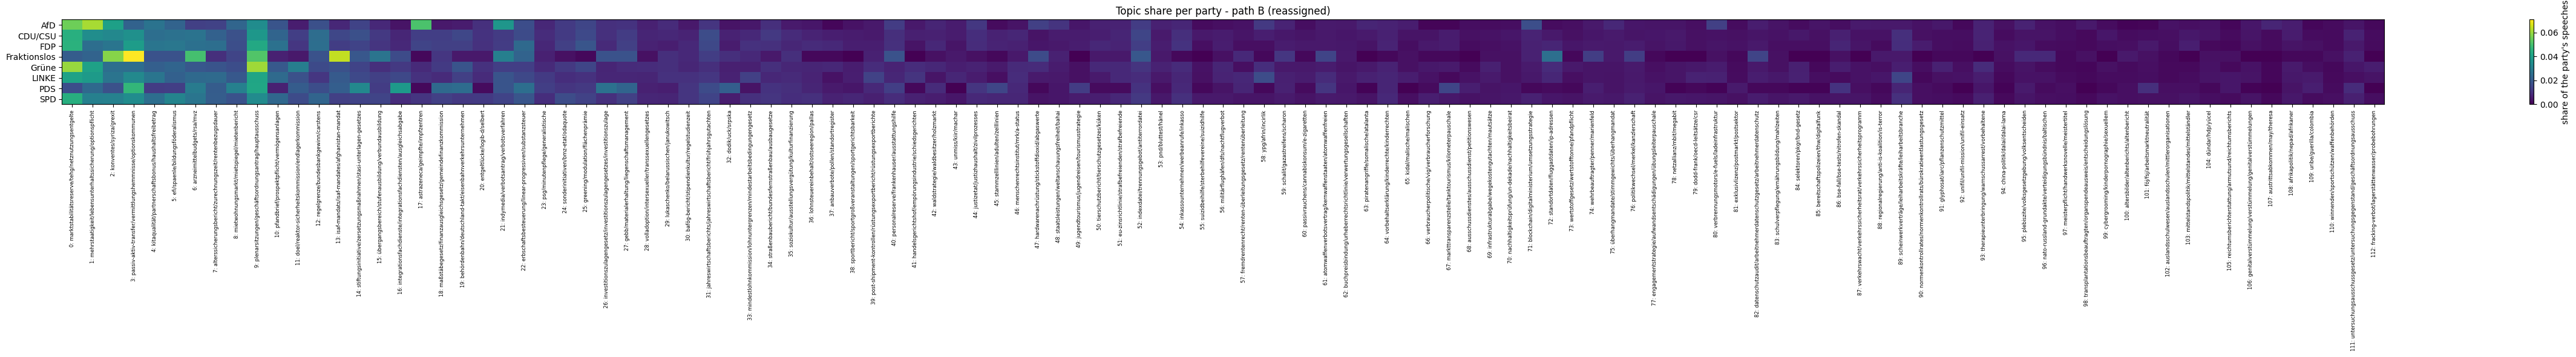

In [9]:
def topic_share_per_party(topic_col, title):
    d = df[df[topic_col] != -1]
    topics = sorted(d[topic_col].unique())
    prof = pd.crosstab(d["party"], d[topic_col], normalize="index")[topics]

    fig, ax = plt.subplots(figsize=(0.4 * len(topics) + 4, 6))
    im = ax.imshow(prof.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels([emb_labels[t] for t in topics], rotation=90, fontsize=6)
    ax.set_yticks(range(len(prof.index))); ax.set_yticklabels(prof.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="share of the party's speeches")
    plt.tight_layout(); plt.show()

topic_share_per_party("topic_emb_raw",  "Topic share per party - path A (raw)")
topic_share_per_party("topic_emb_full", "Topic share per party - path B (reassigned)")

Each **row is a party's topic profile** — the share of *its* speeches on each topic (normalised per party, so parties are comparable despite very different speech counts). Bright cells show where a party over-indexes on a theme; flat columns are shared parliamentary business.

Would be more readable if split in severak graphes with less topics/focus on most important topics.

## 5. Embedding clusters in 2D

In [10]:
import umap
N = 20000
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(N, len(df)), replace=False)
xy = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine",
               init="random", random_state=42).fit_transform(embeddings[idx])

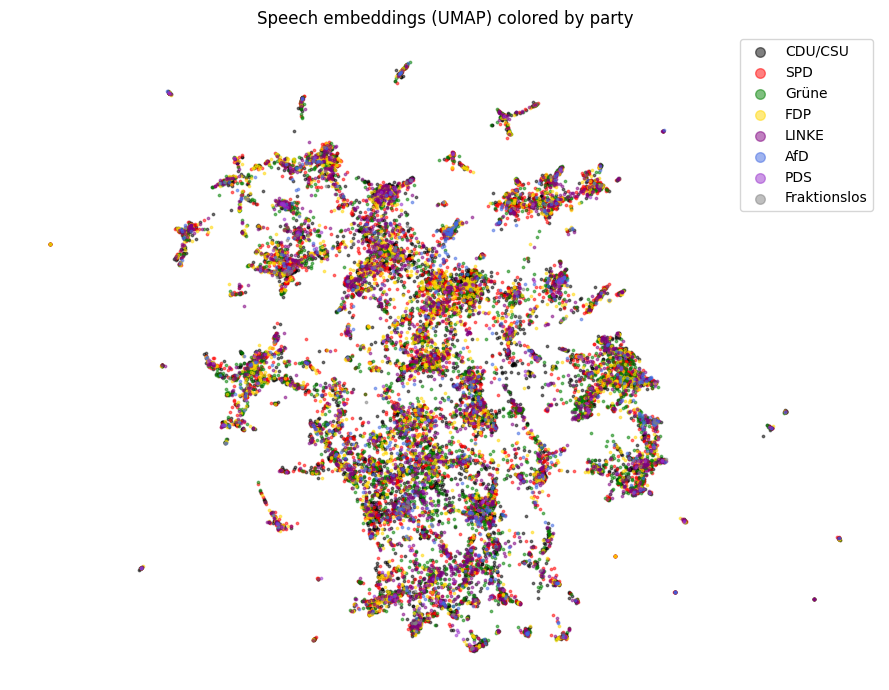

In [11]:
party_sample = df["party"].to_numpy()[idx]
party_colors = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "DIE LINKE.": "purple", "AfD": "royalblue",
                "PDS": "darkorchid", "Fraktionslos": "grey"}

fig, ax = plt.subplots(figsize=(9, 7))
for p, c in party_colors.items():
    m = party_sample == p
    if m.any():
        ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.5, color=c, label=p)
ax.legend(markerscale=4); ax.axis("off")
ax.set_title("Speech embeddings (UMAP) colored by party")
plt.tight_layout(); plt.show()

Speech embeddings in 2D, coloured by **party**. The colours are largely **mixed** — speeches barely separate by party, because what a speech is *about* dominates its embedding far more than who gave it. (This is also why the ideological signal is weak.)

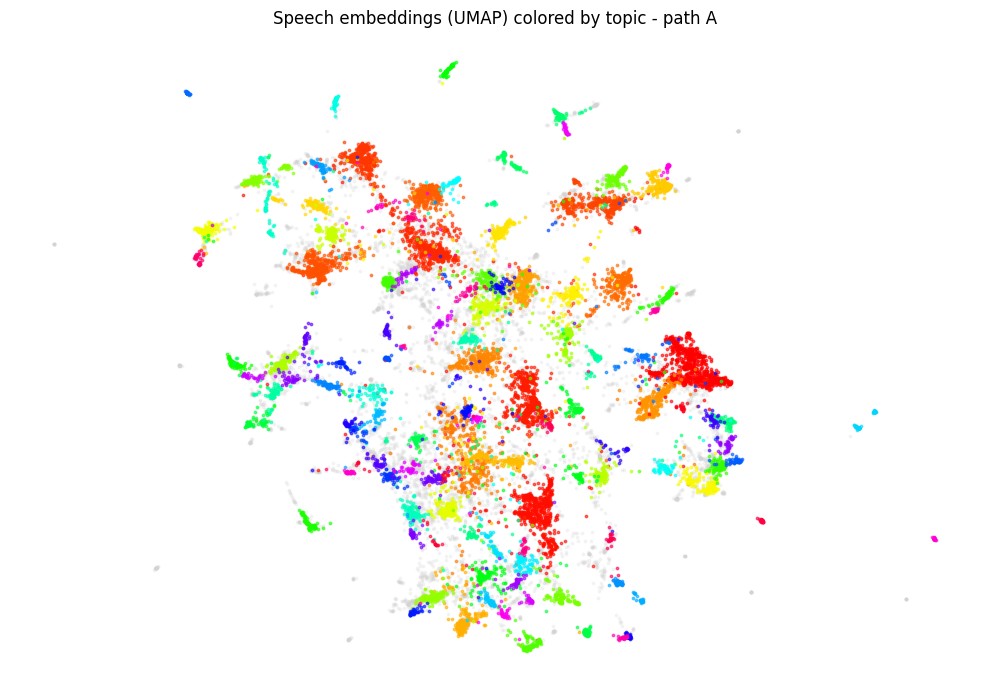

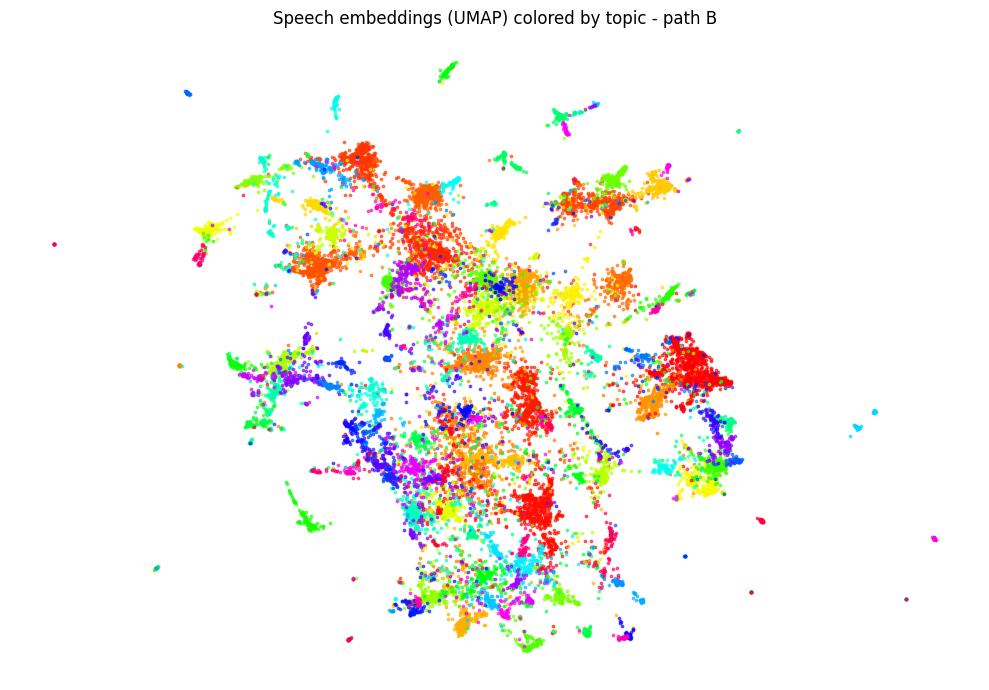

In [12]:
def scatter_by_topic(topic_col, title):
    ts = df[topic_col].to_numpy()[idx]
    topics = [t for t in sorted(set(ts)) if t != -1]
    cmap = plt.get_cmap("hsv", len(topics))
    fig, ax = plt.subplots(figsize=(10, 7))
    m1 = ts == -1
    if m1.any():
        ax.scatter(xy[m1, 0], xy[m1, 1], s=3, alpha=0.2, color="lightgrey", label="-1")
    for i, t in enumerate(topics):
        m = ts == t
        if m.any():
            ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.6, color=cmap(i))
    ax.axis("off"); ax.set_title(title)
    plt.tight_layout(); plt.show()

scatter_by_topic("topic_emb_raw",  "Speech embeddings (UMAP) colored by topic - path A")
scatter_by_topic("topic_emb_full", "Speech embeddings (UMAP) colored by topic - path B")

The same points coloured by **topic** break into clean, separated islands — the embedding space is organised by subject, not party. Path A shows the grey `-1` cloud (unassigned speeches); Path B colours it in.

## 6. Text-based topics (LDA)

LDA gets the same number of topics HDBSCAN found. We print each LDA topic's top words and how many speeches got assigned to it

In [13]:
cv = CountVectorizer(stop_words=german_stop, strip_accents=None, token_pattern=german_token,
                     min_df=20, max_df=0.5, max_features=5000)
dtm = cv.fit_transform(docs)

lda = LatentDirichletAllocation(n_components=n_topics, learning_method="online",
                                batch_size=512, max_iter=15, random_state=42)
doc_topic = lda.fit_transform(dtm)
df["topic_lda"] = doc_topic.argmax(axis=1)
print(f"LDA with {n_topics} topics -", df["topic_lda"].nunique(), "used")

LDA with 113 topics - 110 used


**LDA** is the word-based comparison, run with the same topic count (113 requested, **110 actually used**). Here a speech is assigned by which words co-occur, not by its embedding.

In [14]:
# top words per LDA topic + number of speeches assigned to each
vocab = np.array(cv.get_feature_names_out())
counts_lda = df["topic_lda"].value_counts()
lda_labels = {}
for k in range(lda.n_components):
    top = vocab[lda.components_[k].argsort()[::-1][:8]]
    lda_labels[k] = f"{k}: " + "/".join(top[:2])
    print(f"LDA {k:>2} (n={counts_lda.get(k, 0):>6,}): {', '.join(top)}")

LDA  0 (n= 2,050): arbeitsmarkt, menschen, arbeit, arbeitslosigkeit, beschäftigung, hartz, arbeitslosen, politik
LDA  1 (n=   487): neuen, osten, bundesländern, ddr, ost, einheit, ostdeutschland, west
LDA  2 (n= 1,143): kinder, familien, eltern, kindern, kind, familie, mutter, leben
LDA  3 (n=     8): berlin, sogenannten, berliner, hamburg, stadt, münchen, projekt, stuttgart
LDA  4 (n= 2,651): europäischen, union, europäische, eu, europa, kommission, mitgliedstaaten, frankreich
LDA  5 (n=   162): missbrauch, fälle, verwaltung, personal, personen, fall, ausnahmen, oft
LDA  6 (n=     3): öffentlichen, öffentliche, dienst, beamten, beamte, dienstes, bundes, interesse
LDA  7 (n=     0): lieber, baden-württemberg, niedersachsen, bestätigen, rheinland-pfalz, korrekt, regieren, schulz
LDA  8 (n=   121): länder, bund, ländern, bundes, bundesländer, verantwortung, land, nordrhein-westfalen
LDA  9 (n=     1): bürger, bürgerinnen, bürgern, schweiz, ernstes, staat, landes, akzeptanz
LDA 10 (n=   8

Top words per LDA topic with **speech counts**. Sizes are **uneven** — a few broad topics still absorb many speeches, while keyword-distinct topics (pensions, energy, foreign countries) stay small and clean. This is inherent to LDA with hard (argmax) assignment; the filler stopwords we added shrank the worst generic topics.

### LDA topics on the embedding map

Same 2D UMAP as section 5, coloured by the LDA topic. Clean regions that line up with the embedding blobs = the two methods agree spatially; scattered colours = they carve the speeches differently.

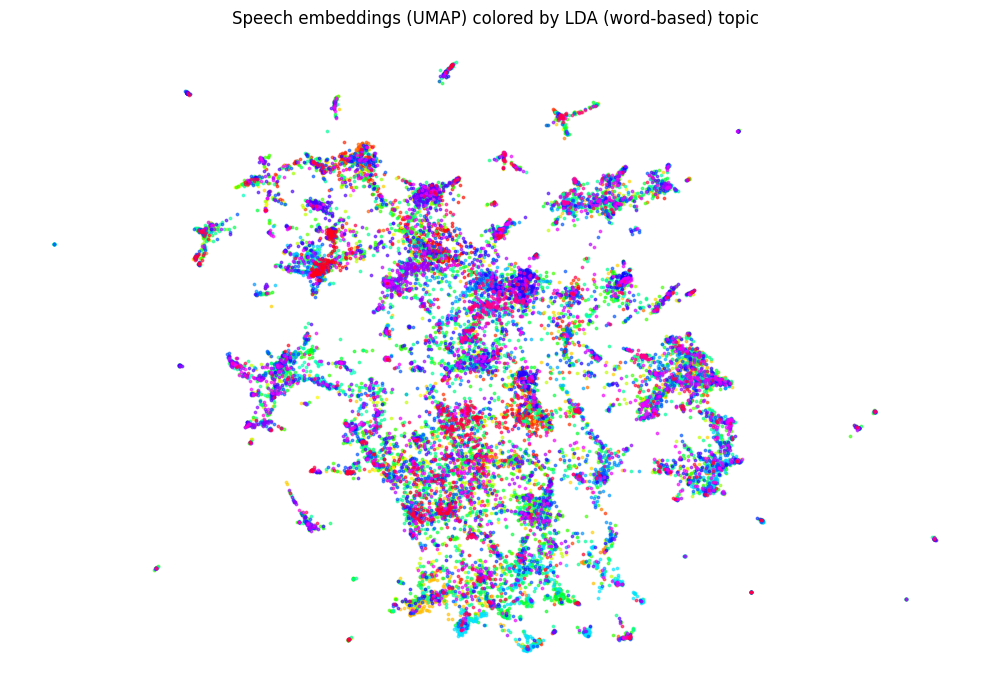

In [15]:
lda_sample = df["topic_lda"].to_numpy()[idx]
topics = sorted(set(lda_sample))
cmap = plt.get_cmap("hsv", len(topics))

fig, ax = plt.subplots(figsize=(10, 7))
for i, t in enumerate(topics):
    m = lda_sample == t
    if m.any():
        ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.6, color=cmap(i))
ax.axis("off")
ax.set_title("Speech embeddings (UMAP) colored by LDA (word-based) topic")
plt.tight_layout(); plt.show()

The embedding map coloured by the **LDA** topic. Where LDA colours form clean regions that line up with the embedding blobs, the two methods agree; where the colours are scattered, they split the speeches differently.

## 7. Compare embedding-based vs text-based

Both sides have the same number of topics. We compare the embedding path B against the LDA labels (cause here all speeches are assigned to a topic)

In [16]:
a = df["topic_emb_full"].to_numpy()
b = df["topic_lda"].to_numpy()
print(f"Adjusted Rand Index: {adjusted_rand_score(a, b):.3f}")
print(f"Normalized Mutual Info: {normalized_mutual_info_score(a, b):.3f}")

Adjusted Rand Index: 0.043
Normalized Mutual Info: 0.223


**How to interpret the scores.** ARI 0.043 / NMI 0.223 is **low, but that is normal** for two different topic algorithms — it means the *exact* speech-by-speech assignments differ, not that the methods found different themes. The real story is in the correspondence table below: specific, keyword-rich topics agree across both methods, while broad / meaning-based topics diverge (that divergence is what embeddings add over the word-based model).

### Which LDA topic matches which embedding topic

The two methods number their topics independently, so there is no built-in mapping - we infer it from overlap. For each embedding topic, we find the LDA topic that most of its speeches fall into. High overlap = a clean one-to-one match; low overlap = that embedding topic is spread across several LDA topics.

In [17]:
ct = pd.crosstab(df["topic_emb_full"], df["topic_lda"], normalize="index")
print(f"{'embedding topic':<34}  ->  {'best LDA match':<30}  overlap")
for emb_t in ct.index:
    lda_t = ct.loc[emb_t].idxmax()
    print(f"{emb_labels[emb_t]:<34}  ->  {lda_labels[lda_t]:<30}  {ct.loc[emb_t, lda_t]:.0%}")

embedding topic                     ->  best LDA match                  overlap
0: marktstabilitätsreserve/tehg/netznutzungsentgelte  ->  14: energien/erneuerbaren       19%
1: mehrstaatigkeit/lebensunterhaltssicherung/optionspflicht  ->  34: menschen/land               14%
2: konventes/syriza/grexit          ->  4: europäischen/union           43%
3: passiv-aktiv-transfer/vermittlungshemmnisse/optionskommunen  ->  0: arbeitsmarkt/menschen        38%
4: kitaqualität/partnerschaftsbonus/haushaltsfreibetrag  ->  2: kinder/familien              28%
5: efi/spaenle/bildungsföderalismus  ->  70: jahren/jahre                14%
6: arzneimittelbudgets/rsa/mvz      ->  112: leistungen/pflege          14%
7: alterssicherungsbericht/zurechnungszeit/rentenbezugsdauer  ->  82: rente/menschen              30%
8: mietwohnungsmarkt/mietspiegel/mietenbericht  ->  75: wohnungen/mieter            13%
9: plenarsitzungen/geschäftsordnungsantrag/hauptausschuss  ->  109: bundestag/parlament        15%
10: pf

For each embedding topic, the LDA topic most of its speeches fall into, plus the **overlap %**. **High overlap (>50%)** = a clean one-to-one match (mostly lexically distinctive topics: pensions, energy, foreign policy). **Low overlap** = the embedding topic is spread across several LDA topics — a theme embeddings capture by meaning that bag-of-words splits by vocabulary.

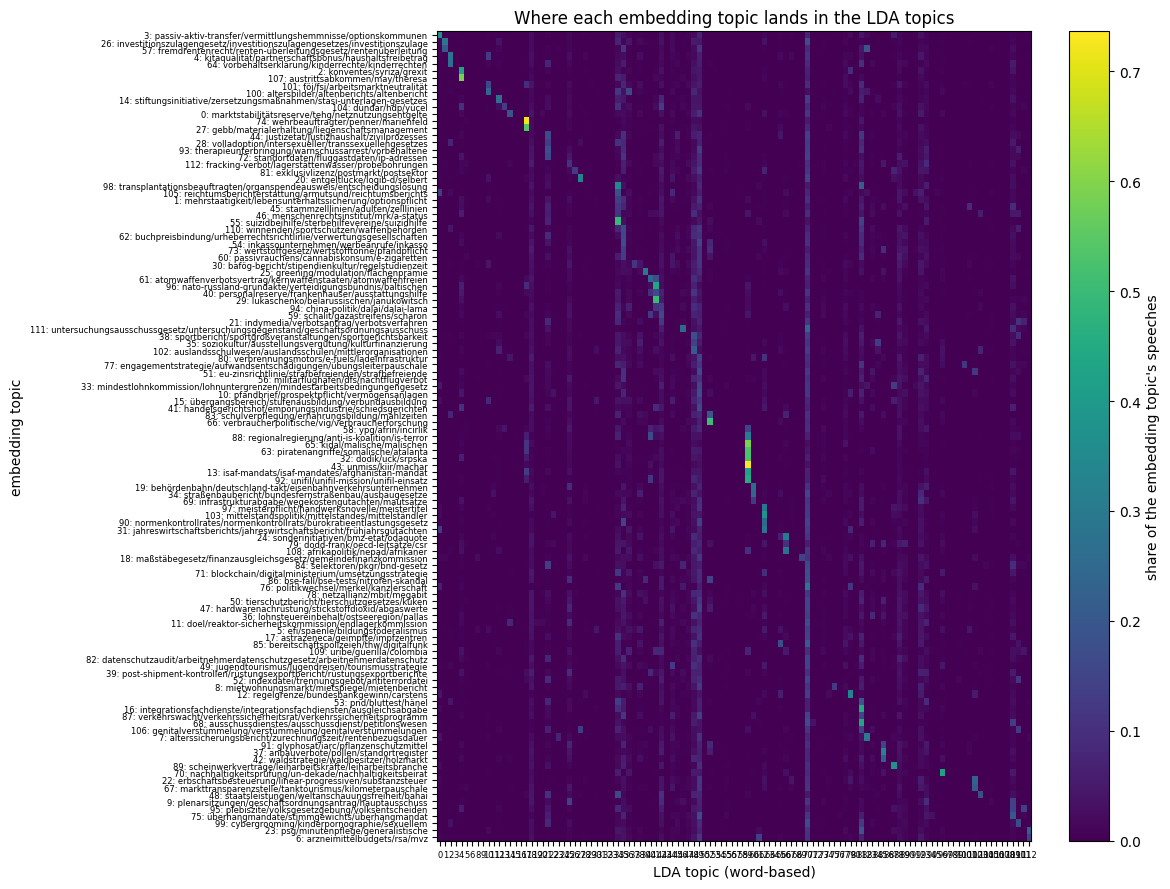

In [18]:
# same table as a heatmap, ordered so the matches line up on the diagonal
ct_plot = ct.iloc[ct.values.argmax(axis=1).argsort()]
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(ct_plot.values, aspect="auto", cmap="viridis")
ax.set_xlabel("LDA topic (word-based)"); ax.set_ylabel("embedding topic")
ax.set_xticks(range(len(ct_plot.columns))); ax.set_xticklabels(ct_plot.columns, fontsize=6)
ax.set_yticks(range(len(ct_plot.index)))
ax.set_yticklabels([emb_labels[t] for t in ct_plot.index], fontsize=6)
ax.set_title("Where each embedding topic lands in the LDA topics")
fig.colorbar(im, ax=ax, label="share of the embedding topic's speeches")
plt.tight_layout(); plt.show()

**Reading it:** a tight diagonal block means an embedding topic maps almost one-to-one onto a single LDA topic - both methods agree that's a real theme. Rows that smear across several LDA columns are where the embeddings merged things LDA splits on vocabulary - that difference is what embeddings add over the word-based model.


## 8. Save the assignments

In [19]:
out = (df[["politicianId", "party", "id", "topic_emb_raw", "topic_emb_full", "topic_lda", "date"]]
       .rename(columns={"politicianId": "speaker_id", "id": "speech_id"}))

out.to_csv("speech_topic_assignments.csv", index=False, encoding="utf-8")
print(f"wrote {len(out):,} rows to speech_topic_assignments.csv")
out.head()

wrote 105,020 rows to speech_topic_assignments.csv


,speaker_id,party,speech_id,topic_emb_raw,topic_emb_full,topic_lda,date
0,11001434,SPD,604683,67,67,18,2000-01-19
1,11002754,CDU/CSU,604883,30,30,47,2000-01-20
2,11000431,SPD,604885,30,30,70,2000-01-20
3,11001180,FDP,604905,36,36,48,2000-01-20
4,11003216,CDU/CSU,605067,74,74,17,2000-01-21


Final deliverable: **`speech_topic_assignments.csv`**, one row per speech — speaker, party, speech id, both embedding topic paths (`topic_emb_raw` / `topic_emb_full`), the LDA topic, and the date. This is what the trajectory notebook reads.